<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Term Frequency - Inverse Document Frequency**


## **Introduction**
A collection of text documents is called a **corpus**. TF-IDF is a common technique for converting a corpus into numerical features that describe which terms are most informative in each document.

TF-IDF stands for **Term Frequency-Inverse Document Frequency**. It combines two ideas: how often a term appears in a document, and how rare or common that term is across the full corpus.

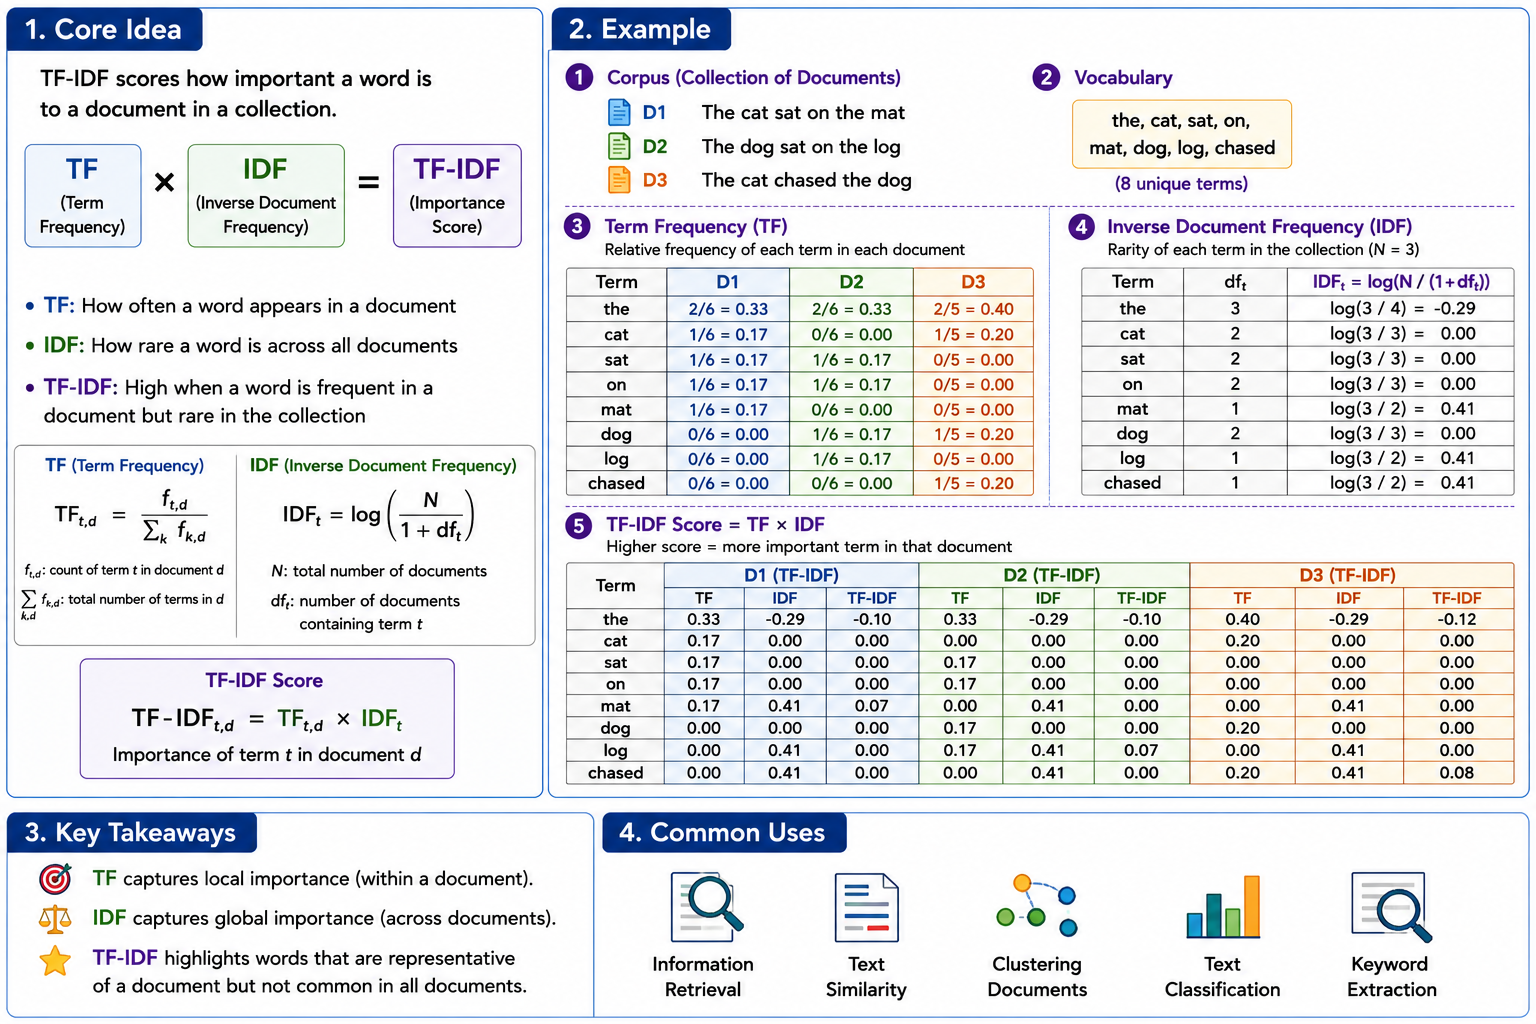
A simple way to interpret TF-IDF is:

- Terms that appear often in a specific document receive higher weight
- Terms that appear in many documents receive lower weight

For example, common words such as `the`, `and`, and `is` may appear frequently but usually provide little information about a document's topic. TF-IDF reduces the influence of these broadly used terms and highlights terms that are more distinctive within a document.

A **term frequency (TF)** matrix counts how many times each term appears in each document:

| Document | science | computer | sports |
|---|---|---|---|
| Doc 1 | 10 | 5 | 0 |
| Doc 2 | 0 | 1 | 12 |

A **TF-IDF matrix** uses the same row-and-column structure, but each value represents the relative importance of a term in a document rather than a raw count:

| Document | science | computer | sports |
|---|---|---|---|
| Doc 1 | 0.82 | 0.65 | 0.01 |
| Doc 2 | 0.02 | 0.10 | 0.91 |

In both matrices, each **row** represents a document and each **column** represents a term. Higher TF-IDF values indicate terms that are more representative of a specific document within the corpus.

TF-IDF is widely used in text analysis tasks such as:

- Document clustering
- Topic modeling
- Search and information retrieval
- Document similarity analysis
- Recommendation systems
- Text classification


### **Workflow**
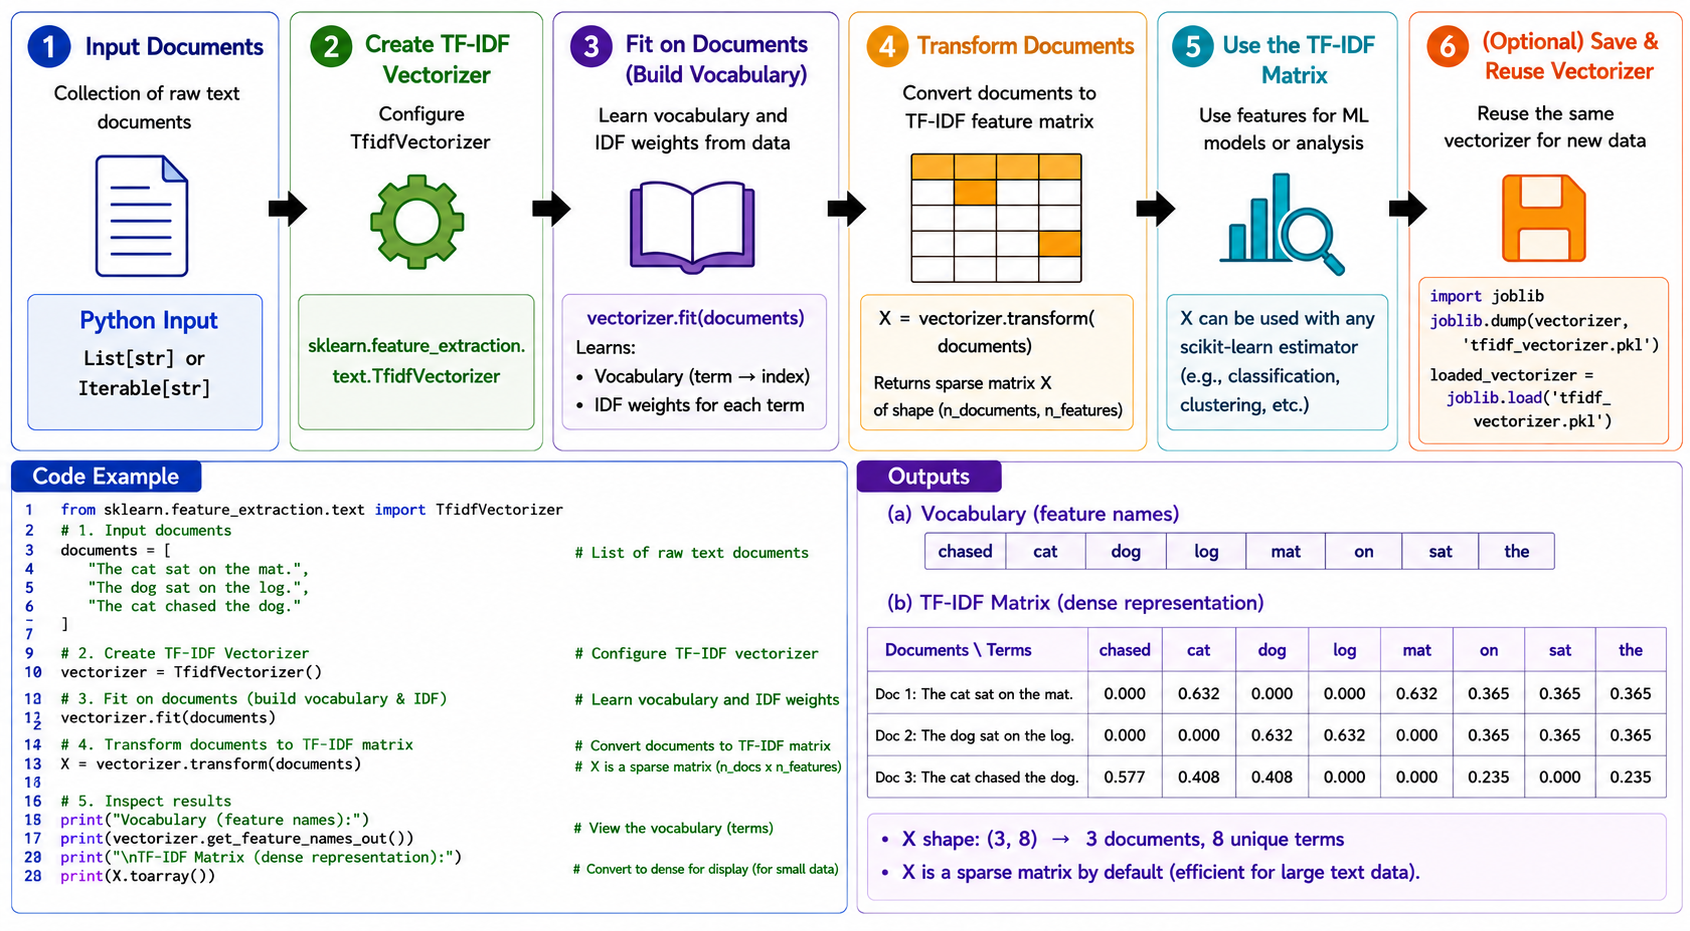

## __Table of Contents__

1. [Objectives](<#Objectives>)
2. [Setup](<#Setup>)
    1. [Installing Required Libraries](<#Installing-Required-Libraries>)
    2. [Importing Required Libraries](<#Importing-Required-Libraries>)
3. [Background](<#Background>)
    1. [Converting to a tf-idf matrix:](<#Converting-to-a-tf-idf-matrix:>)
    2. [Doing it in code](<#Doing-it-in-code>)
4. [Exercises](<#Exercises>)
    1. [Exercise 1 - Count Vectorizering our text](<#Exercise-1---Count-Vectorizering-our-text>)
    2. [Exercise 2 - Applying the tf-idf transformer](<#Exercise-2---Applying-the-tf-idf-transformer>)
    3. [Dense format matrices](<#Dense-format-matrices>)


## **Objectives**

After completing this lab you will be able to:

*   Understand what term frequency and tf-idf matrices are
*   Explain the intuition behind both matrices and how they are calculated
*   Apply tf-idf to a corpus of text and find the most important word in each document


## **Setup**


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.


### **Installing Required Libraries**

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [16]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

### **Importing Required Libraries**

*We recommend you import all required libraries in one place (here):*


In [ ]:
import re
import skillsnetwork
import pandas as pd
import numpy as np
import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from urllib.request import urlopen


# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn
warnings.filterwarnings("ignore")

## **Background**


**Example**

Lets say we have two documents with one sentence each.

*   *"We like dogs and cats"*
*   *"We like cars and planes"*


If we convert these documents into a **term frequency (TF)** matrix, we simply count how many times each word appears in each document.

| doc | we | like | and | dogs | cats | cars | planes |
|---|---|---|---|---|---|---|---|
| 0 | 1 | 1 | 1 | 1 | 1 | 0 | 0 |
| 1 | 1 | 1 | 1 | 0 | 0 | 1 | 1 |

Notice that words such as `we`, `like`, and `and` appear in both documents, while words such as `dogs`, `cats`, `cars`, and `planes` are more specific to individual documents.

A TF matrix only counts word frequency. However, common words that appear in many documents are usually less informative. TF-IDF improves this by reducing the importance of very common words and increasing the importance of more unique words.

The TF-IDF calculation is based on the following equations:

$$
\text{idf}(t) = \log\left(\frac{N}{|\{d \in D : t \in d\}|}\right) + 1
$$

$$
\text{tfidf}(t,d,D) = f_{t,d} \times \text{idf}(t)
$$

Where:

- $f_{t,d}$ = number of times term $t$ appears in document $d$
- $N$ = total number of documents
- $|\{d \in D : t \in d\}|$ = number of documents containing term $t$

The extra `+1` prevents words that appear in every document from receiving a TF-IDF score of zero.


### **Converting to a tf-idf matrix:**


The word `like` appears in both documents, so its importance is relatively low:

$$
1 \times \left(\log\left(\frac{2}{2}\right)+1\right)=1
$$

The word `dogs` appears in only one document, so it receives a higher TF-IDF score:

$$
1 \times \left(\log\left(\frac{2}{1}\right)+1\right)=1.6931
$$

After applying TF-IDF to all terms, the matrix becomes:

| doc | we | like | and | dogs | cats | cars | planes |
|---|---|---|---|---|---|---|---|
| 0 | 1 | 1 | 1 | 1.6931 | 1.6931 | 0 | 0 |
| 1 | 1 | 1 | 1 | 0 | 0 | 1.6931 | 1.6931 |

The resulting matrix highlights words that are more unique and informative for each document.

### **Doing it in code**

This is the function from sklearn that can convert a list of document strings to a term frequency matrix.

```python
CountVectorizer(*, input='content', encoding='utf-8', decode_error='strict', strip_accents=None, lowercase=True, preprocessor=None, tokenizer=None, stop_words=None, token_pattern='(?u)\b\w\w+\b', ngram_range=(1, 1), analyzer='word', max_df=1.0, min_df=1, max_features=None, vocabulary=None, binary=False, dtype=<class 'numpy.int64'>)CountVectorizer(*, input='content', encoding='utf-8', decode_error='strict', strip_accents=None, lowercase=True, preprocessor=None, tokenizer=None, stop_words=None, token_pattern='(?u)\b\w\w+\b', ngram_range=(1, 1), analyzer='word', max_df=1.0, min_df=1, max_features=None, vocabulary=None, binary=False, dtype=<class 'numpy.int64'>)
```

This is the function that converts a term frequency matrix into a tf-idf matrix.

```python
TfidfTransformer(*, norm='l2', use_idf=True, smooth_idf=True, sublinear_tf=False)
```

Lets implement the example above using these functions!


In [18]:
# Corpus
D = ["We like dogs and cats", "We like cars and planes"]

In [ ]:
# Count Vectorizer creates a term frequency matrix
cv = CountVectorizer()
tf_mat = cv.fit_transform(D)
tf = pd.DataFrame(tf_mat.toarray(), columns=cv.get_feature_names_out())
tf

,and,cars,cats,dogs,like,planes,we
0,1,0,1,1,1,0,1
1,1,1,0,0,1,1,1


In [ ]:
# Creating the tfidf matrix
tfidf_trans = TfidfTransformer(smooth_idf=False)
tfidf_mat = tfidf_trans.fit_transform(tf)
tfidf = pd.DataFrame(
    tfidf_mat.toarray(), columns=tfidf_trans.get_feature_names_out()
)

The tf-idf matrix created above by sklearn does some normalization such that the norm (length) of each document vector (row) is 1. We can instead take the idf vector trained on our data and apply it directly to the term frequency matrix to get the non-normalized tf-idf matrix.


In [ ]:
# Non-normalized tf-idf
pd.DataFrame(
    tfidf_trans.idf_ * tf.to_numpy(),
    columns=tfidf_trans.get_feature_names_out(),
)

,and,cars,cats,dogs,like,planes,we
0,1.0,0.000000,1.693147,1.693147,1.0,0.000000,1.0
1,1.0,1.693147,0.000000,0.000000,1.0,1.693147,1.0


In [22]:
# Normalized tf-idf
tfidf

,and,cars,cats,dogs,like,planes,we
0,0.338381,0.000000,0.572929,0.572929,0.338381,0.000000,0.338381
1,0.338381,0.572929,0.000000,0.000000,0.338381,0.572929,0.338381


*Note: These values are different from the ones we manually calculated as sklearn normalizes each document vector.*

*I.e. $\overrightarrow{d} \cdot \overrightarrow{d} = 1$*


In [ ]:
# d
print(tfidf.iloc[0, :])
# d * d
np.multiply(tfidf.iloc[0, :], tfidf.iloc[0, :]).sum().round()

and       0.338381
cars      0.000000
cats      0.572929
dogs      0.572929
like      0.338381
planes    0.000000
we        0.338381
Name: 0, dtype: float64


1.0

## **Exercises**

Lets try creating a tf-idf matrix ourselves! Below we have loaded a [dataset from kaggle](https://www.kaggle.com/datasets/vivmankar/physics-vs-chemistry-vs-biology?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) of text, made up of news documents. This is an open domain dataset that is free to use.


Let's start by loading the data into a `pandas.DataFrame`:

Since you're using `jupyterlite`, you will need to use the following method to load datasets:


In [ ]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%203/data/tfidf.csv"

# df = pd.read_json('tfidf.json')
df = pd.read_csv(urlopen(url)).iloc[:, 1]

Let's look at some samples rows from the dataset we loaded:


In [25]:
df.head(5)

0    Personally I have no idea what my IQ is. I’ve ...
1    I'm skeptical. A heavier lid would be needed t...
2    I think I have 100 cm of books on the subject....
3    Is chemistry hard in uni. Ive read somewhere t...
4    In addition to the other comment, you can crit...
Name: Comment, dtype: object

### **Exercise 1 - Count Vectorizering our text**

Convert this matrix of documents into a term frequency matrix. Note that this dataset has numbers, and we want to remove them for simplicity sake.

Use the following function and plug it into `CountVectorizer(preprocessor=preprocess_text)` as an argument.

We also want to limit the Countvectorizer to just the top 500 words using the `max_features` argument.

**Apply the `CountVectorizer` to the `df` Series and name the columns to the features from the `cv.get_feature_names_out()` function**


In [ ]:
# Lets remove the numbers
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)
    return text

In [ ]:
# Your solution here
cv = CountVectorizer(max_features=500, preprocessor=preprocess_text)
tf = cv.fit_transform(df)
pd.DataFrame(tf.toarray(), columns=cv.get_feature_names_out())

,able,about,above,acid,acids,actually,add,after,again,ago,...,wouldn,wrong,www,yeah,year,years,yes,you,your,yourself
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,10,6,0
1582,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
1583,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
1584,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Exercise 2 - Applying the tf-idf transformer**

Now that we have a term frequency matrix, we can apply the tf-idf function to it in order to obtain a matrix where the values represent how important a certain word is to their documents.

**Apply the TfidfTransformer to the `tf` matrix and name the columns to the features from `CountVectorizer.get_feature_names_out()`**


In [ ]:
# Your solution here
tfidf_trans = TfidfTransformer()
tfidf_mat = tfidf_trans.fit_transform(tf.toarray())
tfidf = pd.DataFrame(tfidf_mat.toarray(), columns=cv.get_feature_names_out())
tfidf

,able,about,above,acid,acids,actually,add,after,again,ago,...,wouldn,wrong,www,yeah,year,years,yes,you,your,yourself
0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,0.11354,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.044232,0.000000,0.0
3,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.188718,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.079460,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,0.00000,0.214699,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.331533,0.308927,0.0
1582,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.096378,0.149678,0.0
1583,0.00000,0.121809,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.225714,0.000000,0.0
1584,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


### **Dense format matrices**

As we can see above, both the term frequency and tf-idf matrices contain a lot of 0's. When dealing with very large corpus of text, or a corpus with a large amount of unique words/features, we will often store the information in a dense format. This saves us space in RAM, as well as reduces the sparsity of the original matrix.


**Normal format:**

| doc | apple | orange | pear |
| --- | ----- | ------ | ---- |
| 0   | 0.5   | 0.3    | 0    |
| 1   | 0     | 0      | 0.4  |

**Dense format:**

| doc | word   | TFIDF Value |
| --- | ------ | ----------- |
| 0   | apple  | 0.5         |
| 0   | orange | 0.3         |
| 1   | pear   | 0.4         |


In code:


In [29]:
tfidf

,able,about,above,acid,acids,actually,add,after,again,ago,...,wouldn,wrong,www,yeah,year,years,yes,you,your,yourself
0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
1,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
2,0.11354,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.044232,0.000000,0.0
3,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.188718,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
4,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.079460,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,0.00000,0.214699,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.331533,0.308927,0.0
1582,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.096378,0.149678,0.0
1583,0.00000,0.121809,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.225714,0.000000,0.0
1584,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


In [30]:
dense_tfidf = tfidf.stack()
dense_tfidf[dense_tfidf != 0]

0     an       0.137536
      and      0.154283
      be       0.109092
      been     0.398127
      by       0.153027
                 ...   
1585  to       0.208749
      up       0.163900
      video    0.559576
      want     0.189222
      you      0.181626
Length: 51427, dtype: float64

## **Authors**


[Richard Ye](https://linkedin.com/in/richard-yehttps://linkedin.com/in/richard-ye?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2022-01-01) is a undergraduate student at the University of Toronto studying Statistics and Finance.

Su Wu

## **Change Log**


| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2022-06-03        | 0.1     | Richard Ye | Create Lab         |
| 2022-06-21        | 0.2     | Steve Hord | QA Pass            |
| 2026-05-16        | 0.3     | Su Wu       | Documentation and code edits|


Copyright © 2022 IBM Corporation. All rights reserved.
